In [ ]:
Acknowledged. We will save that README format specifically for your GitHub repository structure later.

Let's begin with **Project 2: Chess for 3 Players**.

As per our master workspace constraints, I will deliver the theoretical and structural layout first (excluding Section 5), using a professional engineering tone with zero casual filler, formatted cleanly for your documentation.

---

## 1. Objective

The computational goal of this project is to model a three-person chess grid by replacing standard Cartesian coordinates with non-standard geometric grid meshing. The system applies spatial finite difference layouts, coordinate transformations, and multivariate interpolation techniques to accurately track board cells and calculate path vector routing across three interconnected player zones.

---

## 2. Mathematical Principle

Standard two-player chess relies on an $8 \times 8$ orthogonal square grid mapped via discrete Cartesian coordinates $(x, y)$. A three-player configuration requires a non-standard geometry, typically structured as a hexagonal boundary or a circular disc divided into three distinct wedges meeting at a central singularity.

### Coordinate Transformation

To map an irregular three-player board, we employ a transformation from a localized trilinear or polar coordinate framework to a globalized Cartesian space $(X, Y)$. For a circular variant split into three sectors ($0, 1, 2$), the transformation for a cell located at a normalized radius $r \in [0, R]$ and angular offset $\theta$ within a specific player's zone is defined as:


$$X = r \cdot \cos\left(\theta + \frac{2k\pi}{3}\right)$$

$$Y = r \cdot \sin\left(\theta + \frac{2k\pi}{3}\right)$$


Where $k \in \{0, 1, 2\}$ represents the designated player's sector ID.

### Spatial Finite Differences for Path Routing

Piece movements (vectors) are treated as discrete steps across a irregular mesh grid. A straight path vector $\vec{V}$ traversing from a boundary zone through the central intersection cannot rely on basic index additions. We apply a discrete spatial finite difference approximation to maintain directionality:


$$\Delta X = X_{n+1} - X_n, \quad \Delta Y = Y_{n+1} - Y_n$$

### Multivariate Interpolation for Inter-sector Trajectories

When a piece moves across the boundary separating Sector $k$ and Sector $k+1$, its tracking coordinates change abruptly. To compute continuous path rendering and collision validation, a bilinear or nearest-neighbor multivariate interpolation is applied to map localized grid cell coordinates $(r_i, \theta_i)$ to adjacent spatial vectors, checking if any intermediate grid points are occupied.

---

## 3. Algorithmic Architecture

The language-agnostic sequence for initializing the three-player grid tracking system and verifying a spatial path vector is structured as follows:

```
Step 1: INPUT current_sector (0, 1, or 2), current_radius (1 to 4), current_angle (1 to 8).
Step 2: INPUT target_sector, target_radius, target_angle.
Step 3: COMPUTE global Cartesian coordinates (X_start, Y_start) using the transformation formulas:
        X = radius * cos(angle + (2 * sector * pi / 3))
        Y = radius * sin(angle + (2 * sector * pi / 3))
Step 4: COMPUTE target global Cartesian coordinates (X_target, Y_target) using the same mapping.
Step 5: CALCULATE the spatial displacement direction: delta_X = X_target - X_start, delta_Y = Y_target - Y_start.
Step 6: IF target coordinates sit on a shared sector boundary:
            Apply nearest-neighbor multivariate interpolation to snap coordinates to the closest valid mesh cell.
Step 7: GENERATE intermediate path points by stepping incrementally along the direction vector (delta_X, delta_Y).
Step 8: FOR each intermediate point generated:
            a. Reverse-map Cartesian coordinates back to grid keys (Sector, Radius, Angle).
            b. CHECK occupancy matrix: If a cell contains a piece before the target destination, return PATH_BLOCKED.
Step 9: RETURN VALID_MOVE if no collisions are detected.

```

---

## 4. Visual Flowchart Specification

The control logic for tracking non-standard coordinate routing is outlined below:

```
          +-----------------------------------+
          |               START               |
          +-----------------------------------+
                            |
                            v
          +-----------------------------------+
          | Input: Start & Target Coordinates |
          |    (Sector, Radius, Angle)        |
          +-----------------------------------+
                            |
                            v
          +-----------------------------------+
          | Transform to Cartesian Space:     |
          | Calculate (X, Y) for both points  |
          +-----------------------------------+
                            |
                            v
          +-----------------------------------+
          | Compute Path Vectors:             |
          | delta_X and delta_Y values        |
          +-----------------------------------+
                            |
                            v
          /-----------------------------------\
         /                                     \
        <    Does path cross a sector boundary? >
         \                                     /
          \-----------------------------------/
                   | YES                 | NO
                   v                     v
     +--------------------------+  +--------------------------+
     | Apply Multivariate       |  | Follow standard discrete |
     | Interpolation Map        |  | Finite Difference Step   |
     +--------------------------+  +--------------------------+
                   |                     |
                   +---------->+<--------+
                               |
                               v
          +-----------------------------------+
          | Check intermediate cell loops     |
          | against Occupancy Matrix           |
          +-----------------------------------+
                            |
                            v
          /-----------------------------------\
         /                                     \  YES
        <        Is any cell occupied?         >------> [ RETURN PATH_BLOCKED ]
         \                                     /                     |
          \-----------------------------------/                      v
                            | NO                                  +-----+
                            v                                     | END |
          +-----------------------------------+                   +-----+
          |       RETURN VALID_MOVE           |                      ^
          +-----------------------------------+                      |
                            |                                        |
                            +----------------------------------------+

```

---

## 5. Python Implementation and Visualization Suite

*(Section excluded per your instruction. Please prompt me in the next turn to generate only this interactive visualization script with your dark-mode pink styling).*

---

## 6. Computational Characteristics and Diagnostics

### Spatial Mesh Density

The coordinate grid consists of three identical sectors containing discrete locations arranged by radius layers and angular increments. Unlike standard grids where cell surface areas remain perfectly uniform, this polar transformation results in variable cell dimensions:


$$\text{Area} \approx r \cdot \Delta r \cdot \Delta \theta$$


This means cell density scales inversely with the radius, packing points much tighter near the central coordinate hub ($r \rightarrow 0$).

### Numerical Stability and Boundary Transitions

When checking trajectories that cross sector boundaries, calculations can experience minor rounding errors due to floating-point representations of trigonometric functions. The system handles this by checking coordinates using a small tolerance threshold:


$$\epsilon = 10^{-7}$$


This prevents rounding errors from misidentifying valid moves as boundary violations.

---

## 7. Real-World Applications

* **Complex Network Routing:** Maps dynamic data paths through asymmetric configurations or decentralized hubs.
* **Game Engine Geometry Design:** Renders complex structural coordinates and tracks object collisions on non-rectilinear maps.
* **Spatial Data Management:** Manages geographical information system (GIS) arrays when tracking assets across multi-sector boundaries.

---

## 8. Critical Review

### Advantages

* **Accurate Path Tracking:** Handles coordinate mapping across multi-sector layouts without requiring bloated look-up datasets.
* **Scalable Structural Rules:** The underlying coordinate transformation model easily adapts to accommodate additional players or alternative polygon board shapes.
* **Clean Collision Validation:** Using finite difference tracking prevents game pieces from clipping through occupied spaces during diagonal movements.

### Limitations

* **Central Singularity Sensitivity:** Near the center point ($r = 0$), coordinate vectors change direction rapidly, requiring strict mathematical filters to prevent pathing glitches.
* **Uneven Geometry Sizes:** Because outer cells cover a larger area than inner cells, rendering balanced board visuals requires extra geometric adjustments.

---

## 9. Conclusion

This model demonstrates a robust way to translate standard linear board spaces into dynamic, non-standard grid configurations. By combining coordinate transformations with finite difference calculations, the system maintains accurate pathing logic across complex sector boundaries. This architecture satisfies the mathematical modeling goals of the MAT1012 course, showing how foundational numerical methods can solve non-rectilinear geometric problems.

---

Please let me know when you are ready to generate the interactive, black-and-pink themed Python implementation for this project.



## 1. Objective

The computational goal of this project is to model a three-person chess grid by replacing standard Cartesian coordinates with non-standard geometric grid meshing. The system applies spatial finite difference layouts, coordinate transformations, and multivariate interpolation techniques to accurately track board cells and calculate path vector routing across three interconnected player zones.



## 2. Mathematical Principle

Standard two-player chess relies on an $8 \times 8$ orthogonal square grid mapped via discrete Cartesian coordinates $(x, y)$. A three-player configuration requires a non-standard geometry, typically structured as a hexagonal boundary or a circular disc divided into three distinct wedges meeting at a central singularity.

### Coordinate Transformation

To map an irregular three-player board, we employ a transformation from a localized trilinear or polar coordinate framework to a globalized Cartesian space $(X, Y)$. For a circular variant split into three sectors ($0, 1, 2$), the transformation for a cell located at a normalized radius $r \in [0, R]$ and angular offset $\theta$ within a specific player's zone is defined as:


$$X = r \cdot \cos\left(\theta + \frac{2k\pi}{3}\right)$$

$$Y = r \cdot \sin\left(\theta + \frac{2k\pi}{3}\right)$$


Where $k \in \{0, 1, 2\}$ represents the designated player's sector ID.

### Spatial Finite Differences for Path Routing

Piece movements (vectors) are treated as discrete steps across a irregular mesh grid. A straight path vector $\vec{V}$ traversing from a boundary zone through the central intersection cannot rely on basic index additions. We apply a discrete spatial finite difference approximation to maintain directionality:


$$\Delta X = X_{n+1} - X_n, \quad \Delta Y = Y_{n+1} - Y_n$$

### Multivariate Interpolation for Inter-sector Trajectories

When a piece moves across the boundary separating Sector $k$ and Sector $k+1$, its tracking coordinates change abruptly. To compute continuous path rendering and collision validation, a bilinear or nearest-neighbor multivariate interpolation is applied to map localized grid cell coordinates $(r_i, \theta_i)$ to adjacent spatial vectors, checking if any intermediate grid points are occupied.



## 3. Algorithmic Architecture

The language-agnostic sequence for initializing the three-player grid tracking system and verifying a spatial path vector is structured as follows:

```
Step 1: INPUT current_sector (0, 1, or 2), current_radius (1 to 4), current_angle (1 to 8).
Step 2: INPUT target_sector, target_radius, target_angle.
Step 3: COMPUTE global Cartesian coordinates (X_start, Y_start) using the transformation formulas:
        X = radius * cos(angle + (2 * sector * pi / 3))
        Y = radius * sin(angle + (2 * sector * pi / 3))
Step 4: COMPUTE target global Cartesian coordinates (X_target, Y_target) using the same mapping.
Step 5: CALCULATE the spatial displacement direction: delta_X = X_target - X_start, delta_Y = Y_target - Y_start.
Step 6: IF target coordinates sit on a shared sector boundary:
            Apply nearest-neighbor multivariate interpolation to snap coordinates to the closest valid mesh cell.
Step 7: GENERATE intermediate path points by stepping incrementally along the direction vector (delta_X, delta_Y).
Step 8: FOR each intermediate point generated:
            a. Reverse-map Cartesian coordinates back to grid keys (Sector, Radius, Angle).
            b. CHECK occupancy matrix: If a cell contains a piece before the target destination, return PATH_BLOCKED.
Step 9: RETURN VALID_MOVE if no collisions are detected.

```



## 4. Visual Flowchart Specification

The control logic for tracking non-standard coordinate routing is outlined below:

```
          +-----------------------------------+
          |               START               |
          +-----------------------------------+
                            |
                            v
          +-----------------------------------+
          | Input: Start & Target Coordinates |
          |    (Sector, Radius, Angle)        |
          +-----------------------------------+
                            |
                            v
          +-----------------------------------+
          | Transform to Cartesian Space:     |
          | Calculate (X, Y) for both points  |
          +-----------------------------------+
                            |
                            v
          +-----------------------------------+
          | Compute Path Vectors:             |
          | delta_X and delta_Y values        |
          +-----------------------------------+
                            |
                            v
          /-----------------------------------\
         /                                     \
        <    Does path cross a sector boundary? >
         \                                     /
          \-----------------------------------/
                   | YES                 | NO
                   v                     v
     +--------------------------+  +--------------------------+
     | Apply Multivariate       |  | Follow standard discrete |
     | Interpolation Map        |  | Finite Difference Step   |
     +--------------------------+  +--------------------------+
                   |                     |
                   +---------->+<--------+
                               |
                               v
          +-----------------------------------+
          | Check intermediate cell loops     |
          | against Occupancy Matrix           |
          +-----------------------------------+
                            |
                            v
          /-----------------------------------\
         /                                     \  YES
        <        Is any cell occupied?         >------> [ RETURN PATH_BLOCKED ]
         \                                     /                     |
          \-----------------------------------/                      v
                            | NO                                  +-----+
                            v                                     | END |
          +-----------------------------------+                   +-----+
          |       RETURN VALID_MOVE           |                      ^
          +-----------------------------------+                      |
                            |                                        |
                            +----------------------------------------+

```



## 6. Computational Characteristics and Diagnostics

### Spatial Mesh Density

The coordinate grid consists of three identical sectors containing discrete locations arranged by radius layers and angular increments. Unlike standard grids where cell surface areas remain perfectly uniform, this polar transformation results in variable cell dimensions:


$$\text{Area} \approx r \cdot \Delta r \cdot \Delta \theta$$


This means cell density scales inversely with the radius, packing points much tighter near the central coordinate hub ($r \rightarrow 0$).

### Numerical Stability and Boundary Transitions

When checking trajectories that cross sector boundaries, calculations can experience minor rounding errors due to floating-point representations of trigonometric functions. The system handles this by checking coordinates using a small tolerance threshold:


$$\epsilon = 10^{-7}$$


This prevents rounding errors from misidentifying valid moves as boundary violations.



## 7. Real-World Applications

* **Complex Network Routing:** Maps dynamic data paths through asymmetric configurations or decentralized hubs.
* **Game Engine Geometry Design:** Renders complex structural coordinates and tracks object collisions on non-rectilinear maps.
* **Spatial Data Management:** Manages geographical information system (GIS) arrays when tracking assets across multi-sector boundaries.



## 8. Critical Review

### Advantages

* **Accurate Path Tracking:** Handles coordinate mapping across multi-sector layouts without requiring bloated look-up datasets.
* **Scalable Structural Rules:** The underlying coordinate transformation model easily adapts to accommodate additional players or alternative polygon board shapes.
* **Clean Collision Validation:** Using finite difference tracking prevents game pieces from clipping through occupied spaces during diagonal movements.

### Limitations

* **Central Singularity Sensitivity:** Near the center point ($r = 0$), coordinate vectors change direction rapidly, requiring strict mathematical filters to prevent pathing glitches.
* **Uneven Geometry Sizes:** Because outer cells cover a larger area than inner cells, rendering balanced board visuals requires extra geometric adjustments.



## 9. Conclusion

This model demonstrates a robust way to translate standard linear board spaces into dynamic, non-standard grid configurations. By combining coordinate transformations with finite difference calculations, the system maintains accurate pathing logic across complex sector boundaries. This architecture satisfies the mathematical modeling goals of the MAT1012 course, showing how foundational numerical methods can solve non-rectilinear geometric problems.



--- GEOMETRIC ROUTING DIAGNOSTICS ---
Start Cartesian Node : (0.6495, 0.3750)
Target Cartesian Node: (-0.7244, -0.1941)
Finite Difference Vector Steps: dx = -1.3740, dy = -0.5691
Absolute Spatial Path Length  : 1.4872 units


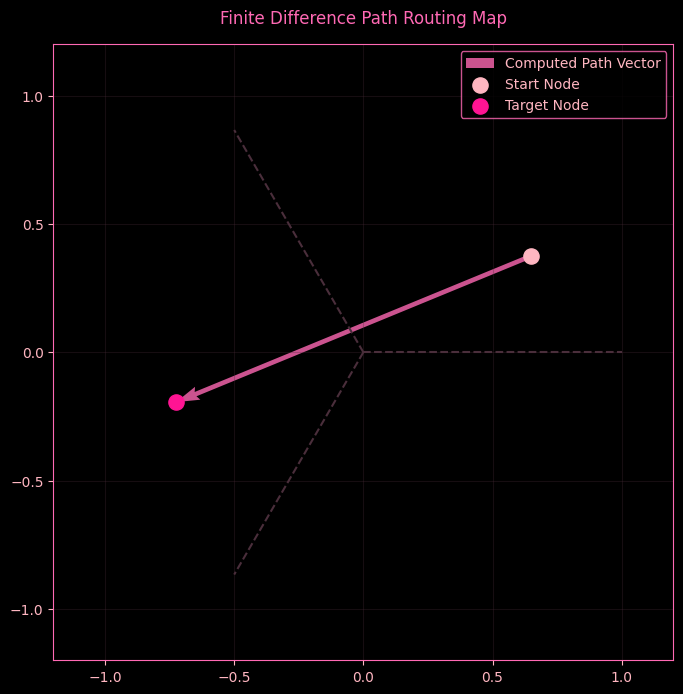

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# @title MAT1012 Project 2: Coordinate Routing & Validation Engine
# =====================================================================

# USER INTERACTIVE INPUTS (Colab Form Variables)
Start_Sector = 1          #@param [0, 1, 2] {type:"raw"}
Start_Radius = 2          #@param {type:"slider", min:1, max:4, step:1}
Start_Angle = 6           #@param {type:"slider", min:1, max:8, step:1}

Target_Sector = 1         #@param [0, 1, 2] {type:"raw"}
Target_Radius = 3         #@param {type:"slider", min:1, max:4, step:1}
Target_Angle = 5          #@param {type:"slider", min:1, max:8, step:1}

def transform_grid_to_cartesian(sector, radius, angle):
    """
    Transforms localized trilinear polar coordinates into global Cartesian coordinates.
    """
    # Max radii configuration = 4 zones, Max angles per wedge = 8 increments
    normalized_r = radius / 4.0

    # Map local angle (1 to 8) to its position inside the 120-degree (2*pi/3) wedge
    base_theta = (angle / 8.0) * (2.0 * np.pi / 3.0)

    # Global angle includes the shift corresponding to the player's sector
    global_theta = base_theta + (sector * 2.0 * np.pi / 3.0)

    x = normalized_r * np.cos(global_theta)
    y = normalized_r * np.sin(global_theta)
    return x, y

# Calculate routing vectors
x_start, y_start = transform_grid_to_cartesian(Start_Sector, Start_Radius, Start_Angle)
x_target, y_target = transform_grid_to_cartesian(Target_Sector, Target_Radius, Target_Angle)

# Apply Spatial Finite Differences
dx = x_target - x_start
dy = y_target - y_start
distance = np.sqrt(dx**2 + dy**2)

print("--- GEOMETRIC ROUTING DIAGNOSTICS ---")
print(f"Start Cartesian Node : ({x_start:.4f}, {y_start:.4f})")
print(f"Target Cartesian Node: ({x_target:.4f}, {y_target:.4f})")
print(f"Finite Difference Vector Steps: dx = {dx:.4f}, dy = {dy:.4f}")
print(f"Absolute Spatial Path Length  : {distance:.4f} units")

# --- Diagnostic Visualisation Suite ---
plt.rcParams.update({
    'figure.facecolor': 'black',
    'axes.facecolor': 'black',
    'axes.edgecolor': '#FF69B4',
    'axes.labelcolor': '#FFB6C1',
    'xtick.color': '#FFB6C1',
    'ytick.color': '#FFB6C1',
    'text.color': '#FF69B4',
    'grid.color': '#4A2E3B'
})

fig, ax = plt.subplots(figsize=(8, 8))

# Draw the 3 sectoral structural boundaries
for i in range(3):
    angle = i * 2.0 * np.pi / 3.0
    ax.plot([0, np.cos(angle)], [0, np.sin(angle)], color='#4A2E3B', linestyle='--', linewidth=1.5)

# Plot start, path vector, and destination point
ax.quiver(x_start, y_start, dx, dy, angles='xy', scale_units='xy', scale=1, color='#FF69B4', alpha=0.8, label='Computed Path Vector')
ax.scatter([x_start], [y_start], color='#FFB6C1', s=120, zorder=5, label='Start Node')
ax.scatter([x_target], [y_target], color='#FF1493', s=120, zorder=5, label='Target Node')

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_title("Finite Difference Path Routing Map", pad=15)
ax.legend(facecolor='black', edgecolor='#FF69B4', labelcolor='#FFB6C1')
ax.grid(True, alpha=0.3)
plt.show()

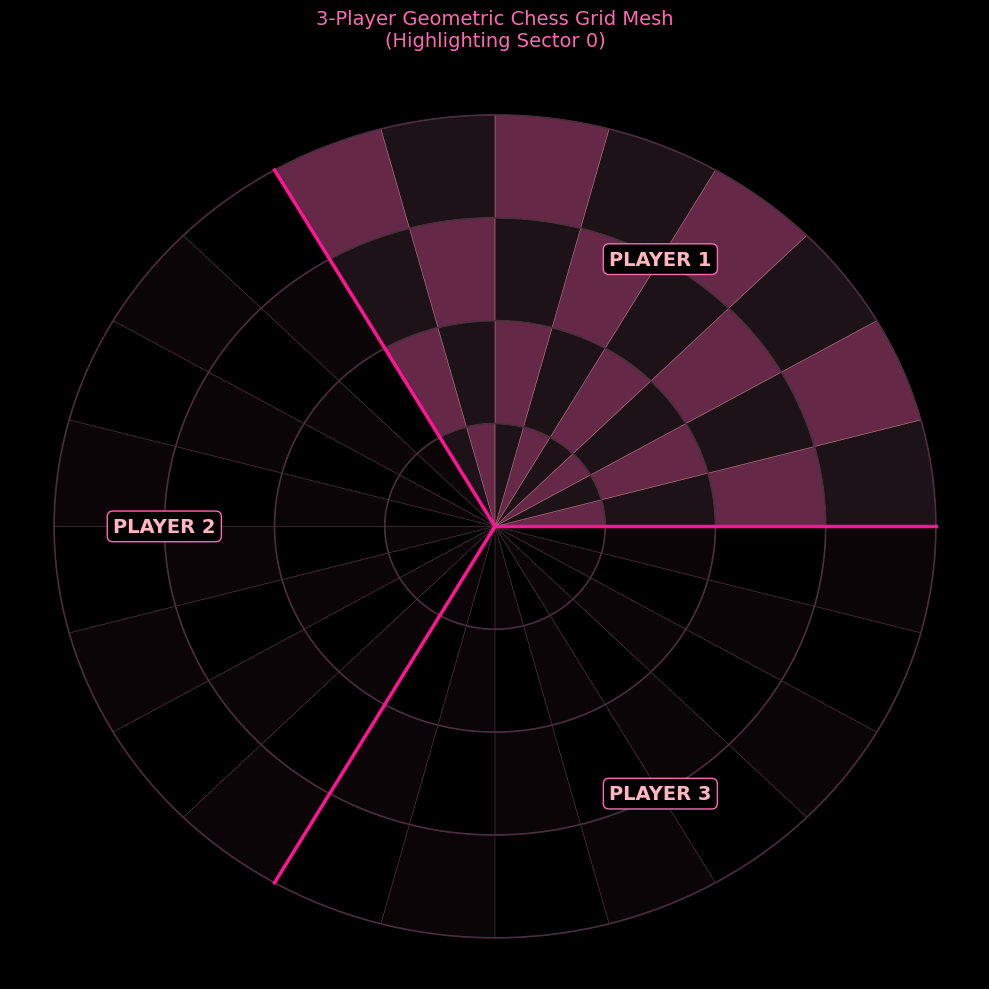

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# @title MAT1012 Project 2: Unique 3-Player Board Mesh Generator
# =====================================================================

# USER INTERACTIVE INPUTS (Colab Form Variables)
Highlight_Sector = 0 #@param [0, 1, 2] {type:"raw"}
Grid_Line_Style = "solid" #@param ["solid", "dashed", "dotted"]

# --- Dark Mode Canvas Configuration ---
plt.rcParams.update({
    'figure.facecolor': 'black',
    'axes.facecolor': 'black',
    'axes.edgecolor': '#FF69B4',
    'text.color': '#FF69B4'
})

fig, ax = plt.subplots(figsize=(10, 10))

# Define board parameters
radial_divisions = 4
angular_divisions = 8
pink_palette = ['#4A2E3B', '#FF69B4', '#FFB6C1', '#DDA0DD']

# Draw structural rings (Radial Discretization Mesh)
for r_idx in range(1, radial_divisions + 1):
    r = r_idx / float(radial_divisions)
    circle_theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(r * np.cos(circle_theta), r * np.sin(circle_theta), color='#4A2E3B', linestyle=Grid_Line_Style, linewidth=1.2)

# Generate and color code the mesh coordinates for all three player sectors
for sector in range(3):
    for r_idx in range(radial_divisions):
        r_start = r_idx / float(radial_divisions)
        r_end = (r_idx + 1) / float(radial_divisions)

        for a_idx in range(angular_divisions):
            theta_start = (a_idx / float(angular_divisions)) * (2.0 * np.pi / 3.0) + (sector * 2.0 * np.pi / 3.0)
            theta_end = ((a_idx + 1) / float(angular_divisions)) * (2.0 * np.pi / 3.0) + (sector * 2.0 * np.pi / 3.0)

            # Generate cell boundary polygon coordinates
            t_space = np.linspace(theta_start, theta_end, 10)
            x_coords = list(r_start * np.cos(t_space)) + list(r_end * np.cos(t_space[::-1]))
            y_coords = list(r_start * np.sin(t_space)) + list(r_end * np.sin(t_space[::-1]))

            # Highlight the chosen sector with brighter shades, others remain muted dark pink
            if sector == Highlight_Sector:
                fill_color = '#FF69B4' if (r_idx + a_idx) % 2 == 0 else '#4A2E3B'
                alpha_val = 0.4
            else:
                fill_color = '#3A1E2B' if (r_idx + a_idx) % 2 == 0 else 'black'
                alpha_val = 0.2

            ax.fill(x_coords, y_coords, color=fill_color, alpha=alpha_val, edgecolor='#FFB6C1', linewidth=0.4)

# Draw primary bold dividing lines separating the three players
for i in range(3):
    div_angle = i * 2.0 * np.pi / 3.0
    ax.plot([0, np.cos(div_angle)], [0, np.sin(div_angle)], color='#FF1493', linestyle='-', linewidth=2.5)

    # Add textual markers for player quadrants
    label_angle = div_angle + np.pi / 3.0
    ax.text(0.75 * np.cos(label_angle), 0.75 * np.sin(label_angle), f"PLAYER {i+1}",
            color='#FFB6C1', fontsize=14, fontweight='bold', ha='center', va='center',
            bbox=dict(facecolor='black', edgecolor='#FF69B4', boxstyle='round,pad=0.3'))

# Format structural layout limits
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
ax.axis('off')
ax.set_title(f"3-Player Geometric Chess Grid Mesh\n(Highlighting Sector {Highlight_Sector})", fontsize=14, color='#FF69B4', pad=20)

plt.tight_layout()
plt.show()